# Algoritmes voor ontwerp van een nok


In [738]:
import numpy as np
import matplotlib.pyplot as plt



<h3>Voorbeeld</h3>

<a id="specs">Bewegingsspecificatie:</a>

- van 20° tot 90°: heffing van +30 mm.
- van 90° tot 120°: heffing van -15 mm.
- van 200° tot 245°: heffing van -15 mm .

De equivalente massa en demping van de volger zijn 18 kg en 0.078.
De volgende statische krachten moeten gerealiseerd worden:

- van 20° tot 90°: een lineair toenemende drukkracht van 0 N tot 375 N.
- van 90° tot 110°: een lineair afnemende drukkracht van 375 N tot 75 N.
- van 210° tot 235°: een constante trekkracht van 340 N.

De beweging moet uitgevoerd zijn in 0.5 seconden.

In [739]:
# specifications:

startangle1 = 20 # degrees
endangle1   = 90 # degrees
theta_seg1  = endangle1 - startangle1 # rotation length for first motion segment
startlift1  =  0
endlift1    = 30
motionlaw1  =  4

startangle2 =  90 # degrees
endangle2   = 120 # degrees
theta_seg2  = endangle2 - startangle2 # rotation length for second segment
startlift2  =  30
endlift2    =  15
motionlaw2  =   4

startangle3 = 120 # degrees
endangle3   = 200 # degrees
theta_seg3  = endangle3 - startangle3 # rotation length for third segment
startlift3  =  15
endlift3    =  15
motionlaw3  =   1

startangle4 = 200 # degrees
endangle4   = 245 # degrees
theta_seg4  = endangle4 - startangle4 # rotation length for fourth segment
startlift4  =  15
endlift4    =   0
motionlaw4  =   4

startangleload1 =   20
endangleload1   =   90
startload1      =    0
endload1        =  375

startangleload2 =   90
endangleload2   =  110
startload2      =  375
endload2        =   75

startangleload3 =  210
endangleload3   =  235
startload3      = -340
endload3        = -340

In [740]:
# Simulation variables of cam:

dtheta = 0.01 # resolution of simulation, in degrees

theta_deg      = np.arange(0,360,dtheta) # array of cam angles in degrees
theta          = theta_deg*np.pi/180     # array of cam angles in radians
lift           = np.zeros(len(theta))    # lift follower in mm
vel            = np.zeros(len(theta))    # velocity follower in mm/rad
vel_deg        = np.zeros(len(theta))    # velocity follower in mm/degree
acc            = np.zeros(len(theta))    # acceleration follower in mm/rad^2
acc_deg        = np.zeros(len(theta))    # acceleration follower in mm/degree^2
ext_load       = np.zeros(len(theta))    # external load in N
pressure_angle = np.zeros(len(theta))    # pressure angle in radians

# Cam design parameters, as output of the analysis
base_radius     = [] # base circle radius in mm
follower_radius = [] # follower radius in mm
exc             = [] # excentricity in mm
mass            = [] # equivalent mass in kg
spring_constant = [] # spring constant in N/mm
spring_preload  = [] # spring preload in N
rpm             = [] # rotations per minute of the cam
omega           = [] # angular velocity of the cam in rad/s

# search space of possible R0 values [mm]:
R0_min          =   0
R0_max          = 100 
R0_delta        =   0.1 
R0_vec          = np.arange(R0_min, R0_max, R0_delta) 
# maximum pressure angle corresponding to the evaluated R0s:
alpha_max       = np.zeros_like(R0_vec)

beta_vec        = np.arange(1, 360, 0.1)  # sampling resolution for rotation
rho_min         = np.zeros_like(beta_vec) # minimal follower radius at each beta

# input parameters of several analysis functions:
beta            = [] # cam angle interval of the segment
startangle      = [] # start angle of the segment in degrees
endangle        = [] # end angle of the segment in degrees
startlift       = [] # start lift of the segment in mm
endlift         = [] # end lift of the segment in mm
startangleload  = [] # start angle of the load in degrees
endangleload    = [] # end angle of the load in degrees
startload       = [] # start load in N
endload         = [] # end load in N
motionlaw       = [] # choice of motion law:
    # 1: dwell,
	  # 2: minimal rms acceleration,
	  # 3: harmonic,
	  # 4: cycloid,
	  # 5: 5th degree poly,
	  # 6: 7th degree poly

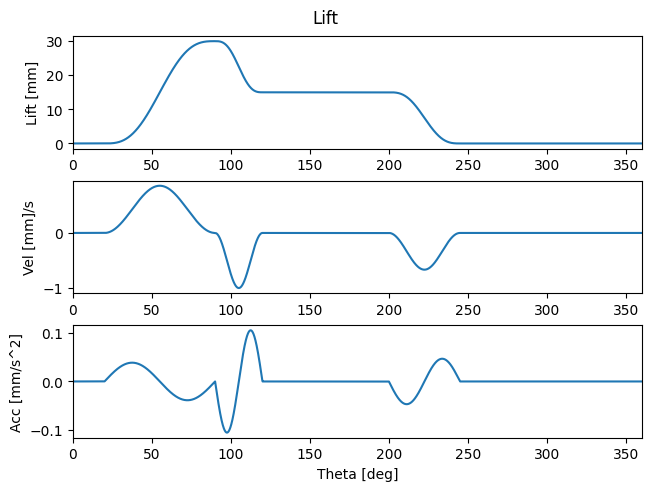

In [741]:
# compute motion functions:

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])


# Add all four segments to the motion law:
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle1,endangle1,startlift1,endlift1,motionlaw1,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle2,endangle2,startlift2,endlift2,motionlaw2,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle3,endangle3,startlift3,endlift3,motionlaw3,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle4,endangle4,startlift4,endlift4,motionlaw4,dtheta)


# Plot the motion law
plotMotionLaw(theta_deg,lift,vel_deg,acc_deg)

plt.show()

In [742]:
# utility functions for external load

def addLoadSegment(startangleload,endangleload,startload,endload,dtheta):
    assert startangleload - endangleload < 0, 'End angle should be bigger than start angle'
    start_index = int(startangleload/dtheta)
    end_index = int(endangleload/dtheta)
    theta_segment = theta_deg[start_index:end_index]
    ext_load[start_index:end_index] = (endload - startload)/(endangleload - startangleload)*(theta_segment - startangleload) + startload

    return ext_load

def plotExternalLoad(theta_deg,ext_load):
    plt.figure()
    plt.plot(theta_deg, ext_load)
    plt.xlabel('Theta [deg]')
    plt.ylabel('External load [N]')
    plt.xlim([0,360])
    plt.title('External load')


In [743]:
# utility functions for cam profile design (with eccentricity = 0!)

# relate sampled R0 values to pressure angle \alpha:
def Kloomok_Muffley_R0(beta,startlift,endlift,motionlaw):
    global R0_vec, alpha_max
    L0 = startlift
    L1 = endlift
    beta = beta * np.pi / 180
		# 100 samples in dimensionless "arc length" of motion law:
    x = np.arange(0, 1, 0.01)

    for i in range(len(R0_vec)):
        R0 = R0_vec[i]

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        alpha = np.arctan2(vel_ang, R0 + lift)
        alpha_max[i] = np.max(np.abs(alpha)) * 180 / np.pi


# relate given R0 value to samples of curvature radii of motion law:
def Kloomok_Muffley_follower_radius(R0,span,startlift,endlift,motionlaw):
    global beta_vec, rho_min
    L0 = startlift
    L1 = endlift

    for i in range(len(beta_vec)):
        beta = beta_vec[i] * np.pi / 180
        theta = np.linspace(0, beta_vec[i], 100) * np.pi / 180
        x = theta / beta

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        rho = ((R0 + lift)**2 + vel_ang**2)**(3/2) / ((R0 + lift)**2 + 2 * vel_ang**2 - (R0 + lift) * acc_ang)
        rho_min[i] = np.min(np.abs(rho))

    plt.figure()
    plt.plot(beta_vec, rho_min)
    plt.axvline(x=span, color='b')
    plt.text(span, 0.35*R0, 'span of this segment: (%s)'%(span), color='b', ha='right', va='center', rotation='vertical')
    plt.grid()
    plt.xlabel(r'rotation (degrees)')
    plt.ylabel(r'$\rho$ (mm)')
    plt.xlim([0, 360])
    plt.show()


In [744]:
# utility functions for pressure angle

def calculatePressureAngle(vel,exc,base_radius,follower_radius,lift):
    pressure_angle = np.arctan((vel-exc)/(np.sqrt((base_radius+follower_radius)**2-exc**2)+lift))
    return pressure_angle

def plotPressureAngle(theta_deg,pressure_angle):
    plt.figure()
    plt.plot(theta_deg, pressure_angle*180/np.pi)
    plt.xlabel('rotation [deg]')
    plt.ylabel('Pressure angle [deg]')
    plt.xlim([0,360])

In [745]:
# utility functions for curvature radius

def calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2) #Nortron, Kinematic and dynamics of Machinery eq. 8.31c
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2 # Nortron, Kinematic and dynamics of Machinery eq. 8.34, adapted for vertical follower instead of a horizontal one (--> + pi/2)
    dlambda = -1 + exc/((d+lift)**2 + exc**2) * vel # derivative of lambda with repect to theta
    ddlambda = exc/((d+lift)**2 + exc**2)*acc - 2*exc*(d+lift)*vel**2/((d+lift)**2 + exc**2)**2 # 2nd derivative of lambda with repect to theta

    g = np.sqrt((d+lift)**2 + exc**2) 
    dg = vel*(d+lift)/np.sqrt((d+lift)**2 + exc**2) # derivative of g with repect to theta
    ddg = (vel**2  + acc*(d + lift))/np.sqrt((d + lift)**2 + exc**2) - (vel**2*(d + lift)**2)/((d + lift)**2 + exc**2)**(3/2) # 2nd derivative of g with repect to theta

    h = np.sin(lambda_)
    dh = np.cos(lambda_)*dlambda # derivative of h with repect to theta
    ddh = -np.sin(lambda_)*dlambda**2 + np.cos(lambda_)*ddlambda # 2nd derivative of h with repect to theta
    f = np.cos(lambda_)
    df = -np.sin(lambda_)*dlambda #derivative of f with repect to theta
    ddf = -np.cos(lambda_)*dlambda**2 - np.sin(lambda_)*ddlambda # 2nd derivative of f with repect to theta

    dx = df*g + f*dg #derivative of x with repect to theta
    ddx = ddf*g + 2*df*dg + f*ddg # 2nd derivative of x with repect to theta
    dy = dh*g + h*dg # derivative of y with repect to theta
    ddy = ddh*g + 2*dh*dg + h*ddg # 2nd derivative of y with repect to theta

    roc_pitch = -(dx**2 + dy**2)**(3/2) / (dx*ddy - dy*ddx) # general forumula for the radius of curvature
    roc_cam = roc_pitch - follower_radius

    return roc_pitch, roc_cam

def plotRadiusCurvature(theta_deg,roc_pitch,roc_cam):
    inds = np.where(np.abs(np.diff(roc_pitch)/dtheta)<1e3)[0]
    maxi = max(10, max(roc_pitch[inds+1]))
    mini = min(-10, min(roc_pitch[inds+1]))
    plt.figure()
    plt.plot(theta_deg, roc_pitch)
    plt.plot(theta_deg, roc_cam)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Radius of curvature [mm]')
    plt.xlim([0,360])
    plt.ylim([mini,maxi])
    plt.grid()
    plt.title('Radius of curvature')

def plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta,):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2
    xpitch = np.cos(lambda_)*np.sqrt((d+lift)**2 + exc**2)
    ypitch = np.sin(lambda_)*np.sqrt((d+lift)**2 + exc**2)

    xcam = xpitch + follower_radius*np.cos(-theta + pressure_angle + 3*np.pi/2)
    ycam = ypitch + follower_radius*np.sin(-theta + pressure_angle + 3*np.pi/2)

    pitch_curve = np.array([xpitch,ypitch])
    cam_curve = np.array([xcam,ycam])

    x_rolfol_center = exc  # x coordinate of the center of the roller of the follower
    y_rolfol_center = d + lift[0]  # y coordinate of the center of the roller of the follower
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center  # x coordinate of the contour of the roller
    y_rolfol = follower_radius * np.sin(theta) + y_rolfol_center  # y coordinate of the contour of the roller

    min_distance_center_roller_to_bore = 2 * follower_radius
    height_bore = follower_radius

    width_block_on_follower = base_radius / 2
    height_block_on_follower = base_radius / 2

    x_boreleft = np.array([exc - 5, exc - 1, exc - 1, exc - 5])
    x_boreright = np.array([exc + 5, exc + 1, exc + 1, exc + 5])
    y_bore = np.array([d + max(lift) + min_distance_center_roller_to_bore] * 2 + [d + max(lift) + min_distance_center_roller_to_bore + height_bore] * 2)
    length_follower = y_bore[-1] - ypitch[0] - follower_radius + 0.2

    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center + follower_radius, y_rolfol_center + follower_radius + length_follower])

    x_block_on_follower = np.array([-width_block_on_follower, width_block_on_follower, width_block_on_follower, -width_block_on_follower]) + x_follower[0]
    y_block_on_follower = np.array([0, 0, height_block_on_follower, height_block_on_follower]) + y_follower[1]

    ref_line = np.array([[0, 0], [0, base_radius]])  # line, indicating the reference (= cam position = 0 degrees)

    x_pressangle = np.array([x_rolfol_center + follower_radius * np.sin(pressure_angle[0]), x_rolfol_center - follower_radius * np.sin(pressure_angle[0])])
    y_pressangle = np.array([y_rolfol_center - follower_radius * np.cos(pressure_angle[0]), y_rolfol_center + follower_radius * np.cos(pressure_angle[0])])

    plt.figure()
    plt.fill(cam_curve[0, ::int(1 / dtheta)], cam_curve[1, ::int(1 / dtheta)], 'b')
    plt.fill(x_rolfol[::int(1 / dtheta)], y_rolfol[::int(1 / dtheta)], 'g')
    plt.plot(pitch_curve[0, ::int(1 / dtheta)], pitch_curve[1, ::int(1 / dtheta)], '--r')
    plt.plot(0, 0, 'r+')
    plt.plot(x_pressangle, y_pressangle, 'r--')
    plt.plot(ref_line[0, :], ref_line[1, :], 'r--')
    plt.plot(x_boreleft, y_bore, 'r')
    plt.plot(x_boreright, y_bore, 'r')
    plt.plot(x_follower, y_follower, 'r')
    plt.fill(x_block_on_follower, y_block_on_follower, 'g')

    xlimits = [min(pitch_curve[0, :]), max(pitch_curve[0, :])]
    ylimits = [min(pitch_curve[1, :]), d + max(lift) + follower_radius + length_follower + height_block_on_follower]

    plt.xlim(np.array(xlimits) * 1.2)
    plt.ylim(np.array(ylimits) * 1.05)
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Cam contour [mm]')

def calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc):
    omega = rpm*2*np.pi/60
    normalforce_spring = (lift*spring_constant+spring_preload)/np.cos(pressure_angle)
    normalforce_load = ext_load/np.cos(pressure_angle)
    normalforce_acc = mass*acc/1000*(omega**2)/np.cos(pressure_angle)
    normalforce_tot = normalforce_spring + normalforce_load + normalforce_acc
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y

def plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y):
    plt.figure()
    plt.plot(theta_deg,normalforce_tot)
    plt.plot(theta_deg,normalforce_acc,'--r')
    plt.plot(theta_deg,normalforce_load,':g')
    plt.plot(theta_deg,normalforce_spring,'-.m')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.legend(['total','acc','extload','spring'])
    plt.title('Normal force')

    plt.figure()
    plt.plot(theta_deg,force_x)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force x [N]')
    plt.xlim([0,360])
    plt.title('Force x')

    plt.figure()
    plt.plot(theta_deg,force_y)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force y [N]')
    plt.xlim([0,360])
    plt.title('Force y')


### Ontwerp van minimale steekcirkel $R_0$

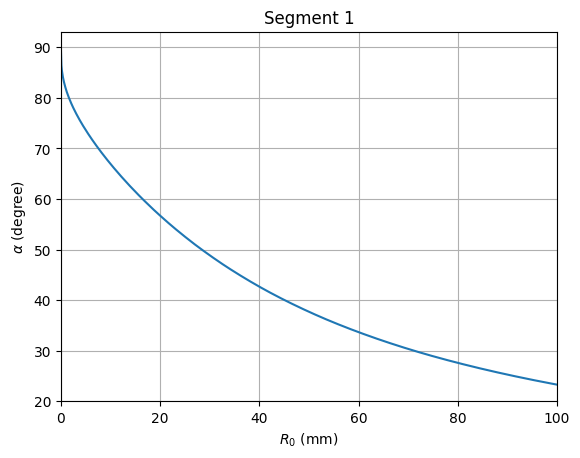

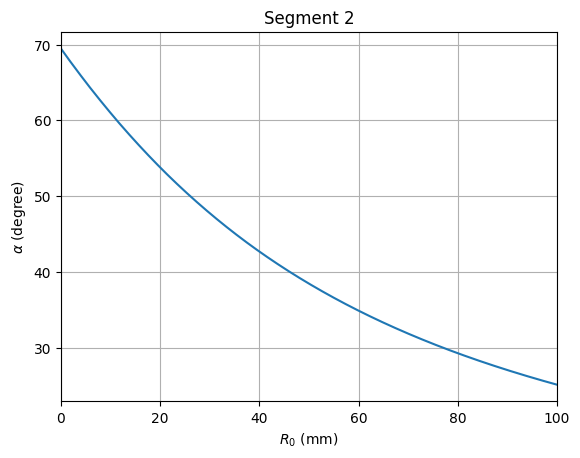

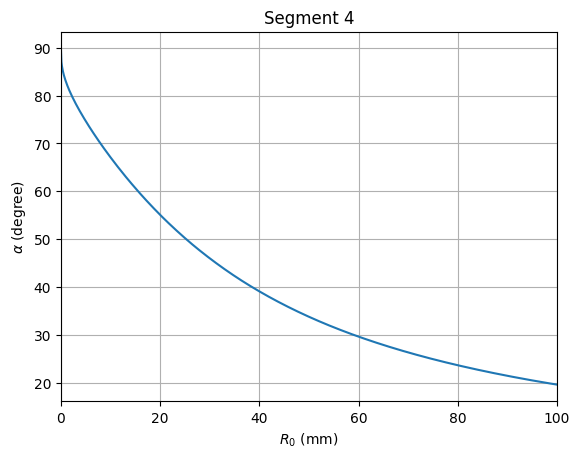

In [746]:
# parameter values for the needed motion segments

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

# The approach was first described by M. Kloomok and R.V. Muffley,
# in Chapter 3 of Mabie, H.H., and Ocvirk, F.W., Mechanisms and Dynamics of Machinery, 1957

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])

# segment 1:
Kloomok_Muffley_R0(theta_seg1,startlift1,endlift1,motionlaw1)

plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 1')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()

# segment 2:
Kloomok_Muffley_R0(theta_seg2,startlift2,endlift2,motionlaw2)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 2')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()

# segment 3:
Kloomok_Muffley_R0(theta_seg4,startlift4,endlift4,motionlaw4)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 4')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()


Uit bovenstaande plots besluiten we dat $R_0 = 80\text{mm}$ een geschikte waarde is.
<br>
(Op basis van alleen maar de vuistregel dat de maximum drukhoek $a_{\text{max}}$ best onder de 30 graden blijft)


In [747]:
R0 = 80  # pitch radius in mm 


Pas op: als je de nokspecificaties aan het <a href="#specs">begin</a> van deze notebook wijzigt, dan kies je misschien voor een andere $R_0$.

### Ontwerp van straal $R_r$ van de volger

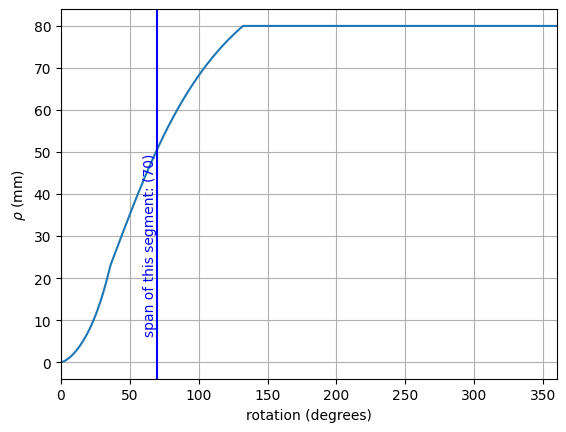

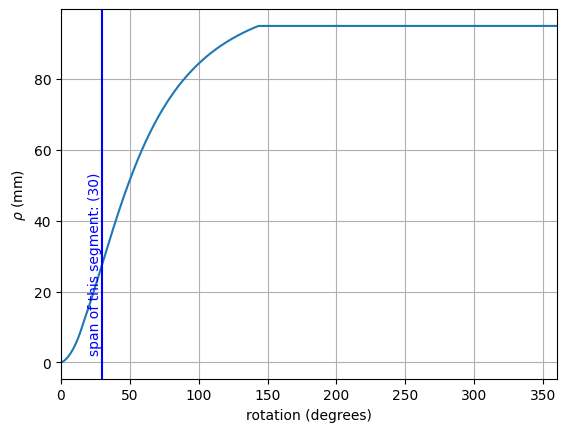

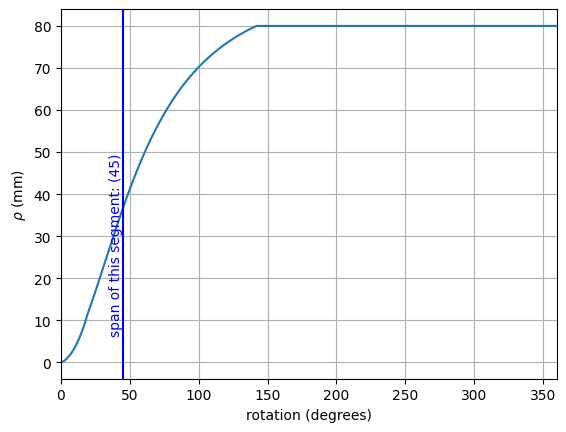

In [748]:
# compute R_r for all segments:

Kloomok_Muffley_follower_radius(R0,theta_seg1,startlift1,endlift1,motionlaw1)
Kloomok_Muffley_follower_radius(R0,theta_seg2,startlift2,endlift2,motionlaw2)
Kloomok_Muffley_follower_radius(R0,theta_seg4,startlift4,endlift4,motionlaw4)

From the plots above, we conclude that the follower radius $R_r$ must be smaller than $50$ mm (segment 1),
$25$ mm (segment 2) and $35$ mm (segment 3).  Let's choose $R_r = 15$ mm. And hence, the base radius of the cam is $R_0 - R_r = 65$ mm.

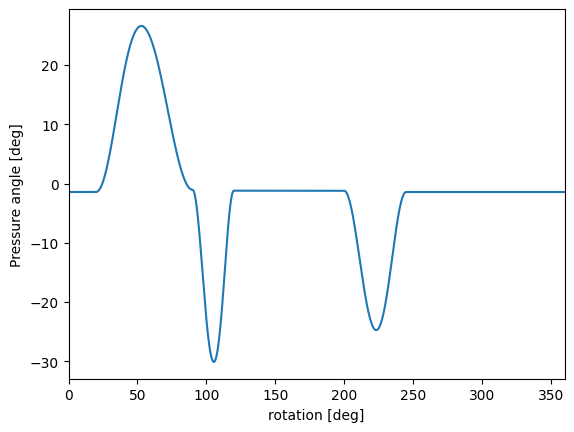

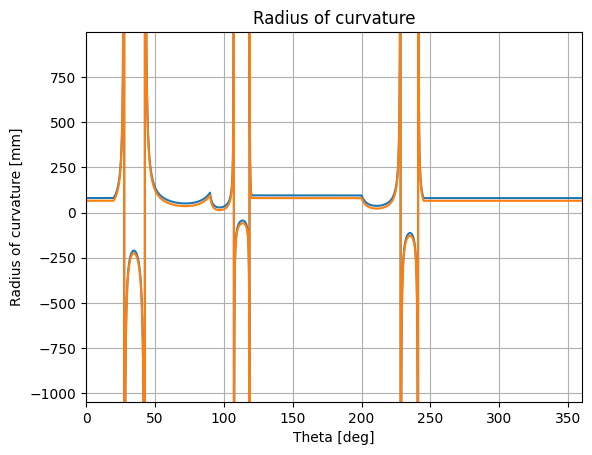

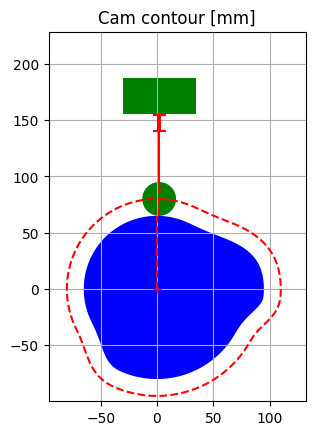

In [749]:
# Kinematics inputs
base_radius     = 65
follower_radius = 15
exc = 2. # try 20 too, to see the difference

# Calculate pressure angle
pressure_angle = calculatePressureAngle(vel,exc,base_radius,follower_radius,lift)
# Plot pressure angle
plotPressureAngle(theta_deg,pressure_angle)

# Calculate radius of curvature
roc_pitch, roc_cam = calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc)

# Plot the radius of curvature
plotRadiusCurvature(theta_deg,roc_pitch,roc_cam)

# Plot the cam contour
plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta)

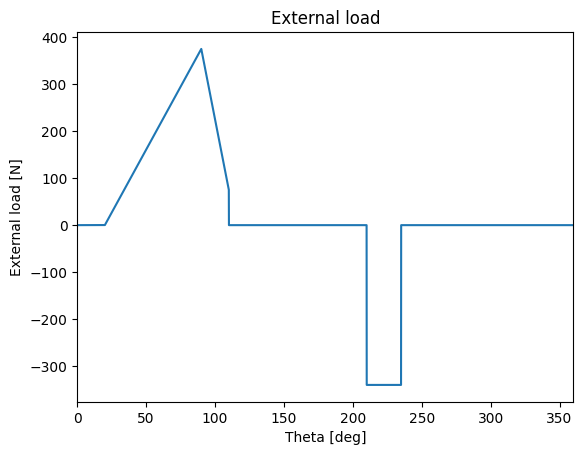

In [750]:
# generate external load

ext_load = addLoadSegment(startangleload1,endangleload1,startload1,endload1,dtheta)
ext_load = addLoadSegment(startangleload2,endangleload2,startload2,endload2,dtheta)
ext_load = addLoadSegment(startangleload3,endangleload3,startload3,endload3,dtheta)

plotExternalLoad(theta_deg,ext_load)

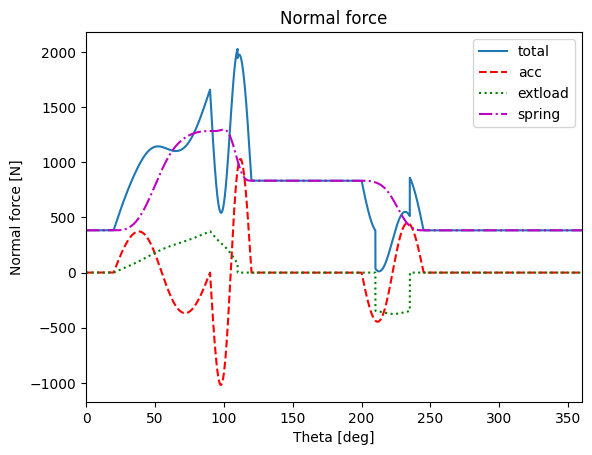

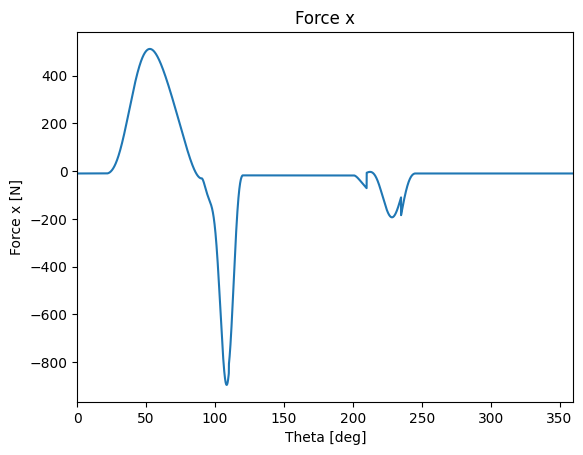

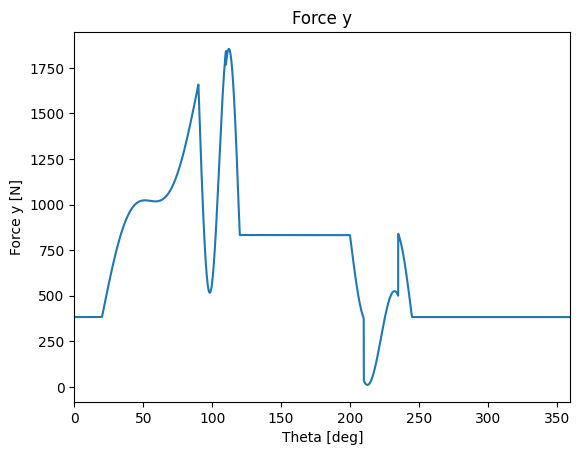

In [751]:
# spring design

# dynamic inputs
mass            =  18
spring_constant =  30
spring_preload  = 383
rpm             = 120

# Calculate forces
[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y] = calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc)
# Plot forces
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y)